<a href="https://colab.research.google.com/github/victoria-e5/credit-scoring/blob/main/competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/SUBMISSION_SCORING_SIFT/'

train = pd.read_csv(base_path + "train.csv")
test = pd.read_csv(base_path + "test.csv")
bureau = pd.read_csv(base_path + "bureau.csv")
prev_loans = pd.read_csv(base_path + "previous_loans.csv")
transactions = pd.read_csv(base_path + "transactions.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


По условию задания посмотрю статистики и размер датасетов

In [ ]:
print(train.shape)
print(' ')
train.info()
print(' ')
train.describe()

(6488, 25)
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6488 entries, 0 to 6487
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   application_id               6488 non-null   int64  
 1   client_id                    6488 non-null   int64  
 2   employment_type              6023 non-null   object 
 3   hash_id                      6071 non-null   float64
 4   region_coefficient_extended  6027 non-null   float64
 5   age                          6039 non-null   float64
 6   incoming_amount              6055 non-null   float64
 7   internal_decision_code       5114 non-null   object 
 8   monthly_income               6047 non-null   float64
 9   application_date             6020 non-null   object 
 10  education                    6040 non-null   object 
 11  requested_product            6106 non-null   object 
 12  channel                      5911 non-null   object 
 13  loan_

,application_id,client_id,hash_id,region_coefficient_extended,age,incoming_amount,monthly_income,loan_amount,post_loan_collection_score,region_coefficient,interest_rate,months_at_job,dependents,days_until_first_overdue,loan_term_months,siberia_northern_score,target
count,6488.000000,6488.000000,6.071000e+03,6027.000000,6039.000000,6055.000000,6047.000000,5932.000000,4950.000000,6132.0,6113.000000,6102.000000,6018.000000,4632.000000,5961.000000,6056.000000,6488.000000
mean,104496.386868,4496.386868,5.503946e+07,0.005973,43.636529,42386.646533,42300.330501,77673.946999,490.591644,1.0,0.270003,102.636676,0.805085,580.034111,20.849019,0.505414,0.342170
std,2592.661534,2592.661534,2.594531e+07,0.077061,13.600516,21867.000385,21759.337138,45118.826338,225.343839,0.0,0.096328,86.869559,0.900978,436.833759,11.907587,0.288577,0.474473
min,100001.000000,1.000000,1.000185e+07,0.000000,21.000000,18000.000000,18000.000000,20000.000000,0.000000,1.0,0.080000,0.000000,0.000000,1.000000,6.000000,0.000109,0.000000
25%,102256.500000,2256.500000,3.237164e+07,0.000000,32.000000,26815.515000,26777.040000,47056.442500,320.677500,1.0,0.193000,36.000000,0.000000,97.000000,12.000000,0.257933,0.000000
50%,104518.500000,4518.500000,5.501823e+07,0.000000,44.000000,37773.110000,37717.510000,67344.210000,472.205000,1.0,0.250800,80.000000,1.000000,730.000000,18.000000,0.509269,0.000000
75%,106714.500000,6714.500000,7.818919e+07,0.000000,55.000000,52218.765000,52181.895000,96352.650000,659.425000,1.0,0.332300,149.000000,1.000000,1000.000000,24.000000,0.754349,1.000000
max,109000.000000,9000.000000,9.999550e+07,1.000000,67.000000,282686.980000,282686.980000,496150.840000,1000.000000,1.0,0.480000,506.000000,5.000000,1002.000000,48.000000,0.999899,1.000000


In [ ]:
print(test.shape)
print(' ')
test.info()
print(' ')
test.describe()

(2520, 24)
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   application_id               2520 non-null   int64  
 1   client_id                    2520 non-null   int64  
 2   region_coefficient_extended  2314 non-null   float64
 3   loan_term_months             2360 non-null   float64
 4   siberia_northern_score       2352 non-null   float64
 5   hash_id                      2291 non-null   float64
 6   loan_amount                  2351 non-null   float64
 7   post_loan_collection_score   0 non-null      float64
 8   months_at_job                2329 non-null   float64
 9   channel                      2315 non-null   object 
 10  education                    2345 non-null   object 
 11  internal_decision_code       0 non-null      float64
 12  monthly_income               2284 non-null   float64
 13  regio

,application_id,client_id,region_coefficient_extended,loan_term_months,siberia_northern_score,hash_id,loan_amount,post_loan_collection_score,months_at_job,internal_decision_code,monthly_income,days_until_first_overdue,incoming_amount,age,dependents,interest_rate,region_coefficient
count,2520.000000,2520.000000,2314.000000,2360.000000,2352.000000,2.291000e+03,2351.000000,0.0,2329.000000,0.0,2284.000000,0.0,2318.000000,2322.000000,2365.000000,2317.000000,2351.0
mean,104509.963095,4509.963095,0.003889,20.505508,0.503897,5.490572e+07,78265.656159,NaN,102.082439,NaN,42128.436581,NaN,42065.310738,43.946598,0.801691,0.267957,1.0
std,2612.549464,2612.549464,0.062257,11.599870,0.290296,2.614188e+07,45163.700324,NaN,87.850046,NaN,21195.124881,NaN,21131.202253,13.502092,0.903554,0.094078,0.0
min,100002.000000,2.000000,0.000000,6.000000,0.000896,1.004359e+07,20000.000000,NaN,0.000000,NaN,18000.000000,NaN,18000.000000,21.000000,0.000000,0.094700,1.0
25%,102218.250000,2218.250000,0.000000,12.000000,0.251946,3.197252e+07,46888.620000,NaN,35.000000,NaN,26683.157500,NaN,26614.375000,32.000000,0.000000,0.192700,1.0
50%,104454.500000,4454.500000,0.000000,18.000000,0.510454,5.578085e+07,67730.790000,NaN,79.000000,NaN,37825.845000,NaN,37680.640000,44.000000,1.000000,0.247400,1.0
75%,106875.000000,6875.000000,0.000000,24.000000,0.755153,7.774957e+07,98272.030000,NaN,147.000000,NaN,51860.830000,NaN,51848.940000,55.000000,1.000000,0.332400,1.0
max,108998.000000,8998.000000,1.000000,48.000000,0.997266,9.995308e+07,537558.790000,NaN,524.000000,NaN,196085.590000,NaN,196085.590000,67.000000,5.000000,0.480000,1.0


In [ ]:
print(bureau.shape)
print(' ')
bureau.info()
print(' ')
bureau.describe()

(24689, 8)
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24689 entries, 0 to 24688
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   client_id          24689 non-null  int64  
 1   bureau_account_id  24689 non-null  object 
 2   account_type       23852 non-null  object 
 3   opened_days_ago    24037 non-null  float64
 4   credit_limit       23862 non-null  float64
 5   current_balance    24209 non-null  float64
 6   max_dpd_last_12m   23832 non-null  float64
 7   bureau_status      23414 non-null  object 
dtypes: float64(4), int64(1), object(3)
memory usage: 1.5+ MB
 


,client_id,opened_days_ago,credit_limit,current_balance,max_dpd_last_12m
count,24689.000000,24037.000000,23862.000000,24209.000000,23832.000000
mean,4503.892584,1530.544952,73635.370562,31605.814437,9.955102
std,2601.993418,851.999018,52976.082696,29566.123851,20.058778
min,1.000000,60.000000,5162.010000,208.920000,0.000000
25%,2246.000000,788.000000,38598.330000,12849.940000,0.000000
50%,4537.000000,1526.000000,59774.735000,23324.850000,1.000000
75%,6766.000000,2274.000000,92573.527500,40686.930000,7.000000
max,9000.000000,2999.000000,823503.730000,589438.390000,90.000000


In [ ]:
print(prev_loans.shape)
print(' ')
prev_loans.info()
print(' ')
prev_loans.describe()

(12762, 7)
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12762 entries, 0 to 12761
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   client_id             12762 non-null  int64  
 1   previous_loan_id      12762 non-null  object 
 2   previous_amount       12445 non-null  float64
 3   previous_term_months  12117 non-null  float64
 4   closed_days_ago       12246 non-null  float64
 5   was_overdue           12496 non-null  float64
 6   max_overdue_days      12318 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 698.1+ KB
 


,client_id,previous_amount,previous_term_months,closed_days_ago,was_overdue,max_overdue_days
count,12762.000000,12445.000000,12117.000000,12246.000000,12496.000000,12318.000000
mean,4512.050306,56621.215050,15.324090,813.172709,0.215589,3.866131
std,2598.207487,33839.413872,10.647548,457.405745,0.411247,12.819714
min,2.000000,6101.880000,3.000000,20.000000,0.000000,0.000000
25%,2232.000000,33506.610000,6.000000,417.000000,0.000000,0.000000
50%,4545.500000,48665.570000,12.000000,813.500000,0.000000,0.000000
75%,6739.750000,70704.430000,24.000000,1215.000000,0.000000,0.000000
max,9000.000000,527095.240000,36.000000,1599.000000,1.000000,90.000000


In [ ]:
print(transactions.shape)
print(' ')
transactions.info()
print(' ')
transactions.describe()

(353300, 6)
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353300 entries, 0 to 353299
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   client_id             353300 non-null  int64  
 1   application_id        353300 non-null  int64  
 2   transaction_date      342664 non-null  object 
 3   transaction_category  335599 non-null  object 
 4   amount                341886 non-null  float64
 5   merchant_risk_level   338285 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 16.2+ MB
 


,client_id,application_id,amount,merchant_risk_level
count,353300.000000,353300.000000,341886.000000,338285.000000
mean,4498.879856,104498.879856,-351.372813,2.281629
std,2597.796811,2597.796811,11658.936876,1.219794
min,1.000000,100001.000000,-99514.770000,1.000000
25%,2249.000000,102249.000000,-3573.080000,1.000000
50%,4495.000000,104495.000000,-1840.155000,2.000000
75%,6748.000000,106748.000000,-850.822500,3.000000
max,9000.000000,109000.000000,788077.580000,5.000000


In [ ]:
train['target'].value_counts(normalize=True)
#здесь я считаю долю нулей и единиц в целевой переменной (таргете),
# чтобы иметь это в виду при обучении (вдруг там дисбаланс классов)

,proportion
target,
0,0.65783
1,0.34217


0 - 65.8% - доля тех, кто не вышел в серьезную просрочку.

1 - 34.2% - доля тех, кто вышел в серьезную просрочку в течение 90 дней после выдачи займа.

НО доля дефолта высока, то есть сегмент с высоким риском от заемщиков (просто наблюдение, на обучение не должно повлиять)

Ниже приведу наглядную визуализацию дисбаланса классов

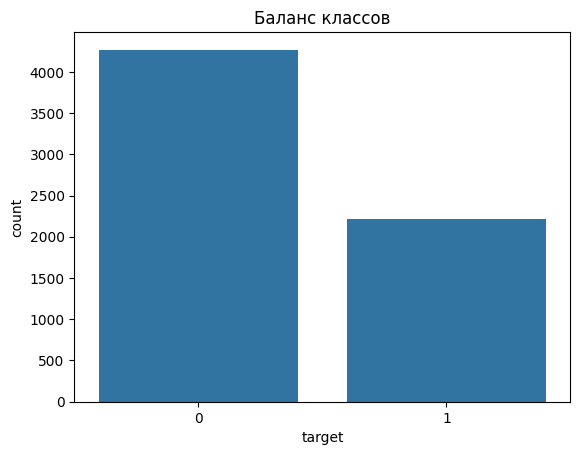

In [ ]:
sb.countplot(data=train, x='target')
plt.title('Баланс классов')
plt.show()
#непосредственно визуализация баланса классов для таргета

По графику можно увидеть, что дисбаланс небольшой, около 2 к 1.
Это хорошо, потому что делать ничего не нужно, модель сама справится и хорошо обучится. Тем более у нас метрика Roc-AUC нечувствительна к дисбалансу.

In [ ]:
train.isnull().mean().sort_values(ascending=False).head(10)
#Здесь ищем пропуски (долю пропусков) в train и сортируем по убыванию.
#Это важно, тк если окажется что в колонке слишком много пропусков,
#(более половины строк), то колонка может быть бесполезна для обучения,
#а если пропусков совсем немного, то для бустинга это не страшно.
#Для логрега придётся заполнять (буду использовать логистическую регрессию как baseline).

,0
days_until_first_overdue,0.286067
post_loan_collection_score,0.237053
internal_decision_code,0.211776
channel,0.088933
loan_amount,0.085697
region,0.084155
loan_term_months,0.081227
marketing_segment,0.078607
dependents,0.072441
application_date,0.072133


In [ ]:
#то же самое для bureau
bureau.isnull().mean().sort_values(ascending=False).head(10)

,0
bureau_status,0.051642
max_dpd_last_12m,0.034712
account_type,0.033902
credit_limit,0.033497
opened_days_ago,0.026409
current_balance,0.019442
client_id,0.000000
bureau_account_id,0.000000


In [ ]:
#и то же самое для previous_loans
prev_loans.isnull().mean().sort_values(ascending=False).head(10)

,0
previous_term_months,0.050541
closed_days_ago,0.040433
max_overdue_days,0.034791
previous_amount,0.024839
was_overdue,0.020843
previous_loan_id,0.000000
client_id,0.000000


In [ ]:
#и то же самое для transactions
transactions.isnull().mean().sort_values(ascending=False).head(10)

,0
transaction_category,0.050102
merchant_risk_level,0.042499
amount,0.032307
transaction_date,0.030105
application_id,0.000000
client_id,0.000000


Пропусков много, но я буду использовать бустинг, а он сам с ними справляется, поэтому не критично.

Но если пропусков будет слишком много (более 80%) - вырежу их как бесполезные признаки ниже в FE.

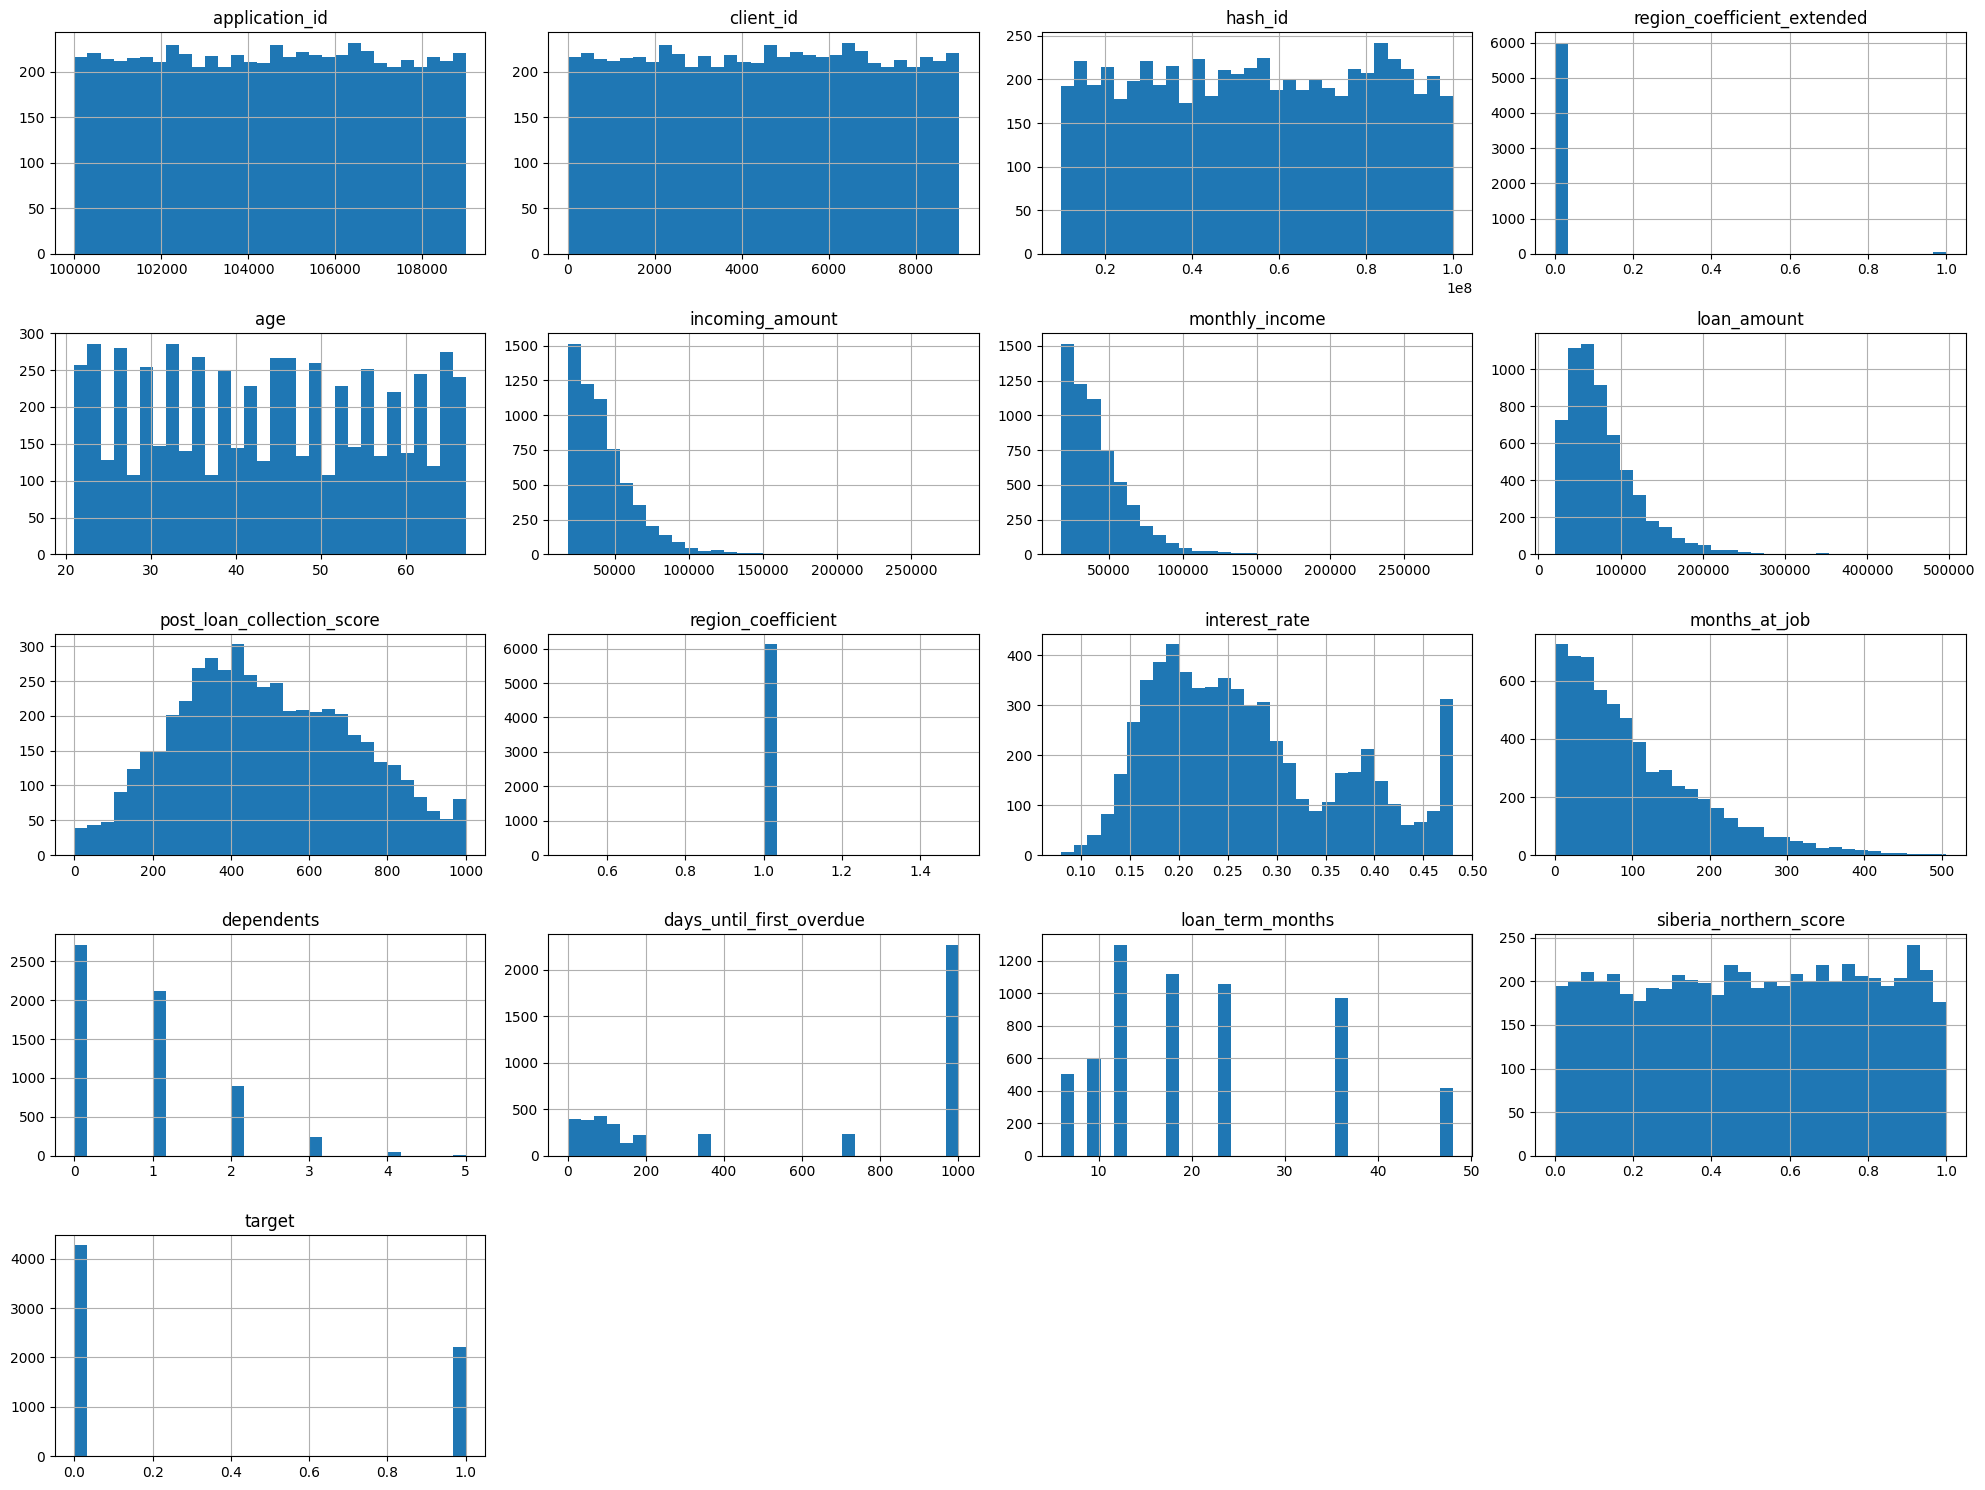

In [ ]:
train.hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()
#Здесь будут гистограммы распределений по всем колонкам.

несколько моментов по гистограммам:

1 region_coefficient - константа, которая всюду равна 1, бесполезная фича, которую я вырежу в feature engineering части.

2 incoming_amount и monthly_income - распределения одинаковые. Проверю на матрице корреляции, один из двоих уберу.


3 days_until_first_overdue - максимум на 1000,
  похоже на заглушку для тех, кто не просрочил. Есть риск, что модель не поймет смысла заглушки и посчитает, что это просто просрочка через 1000 дней (как будто просрочка была, но ее не было). Надо вырезать.


4 loan_term_months - дискретные значения, буду считать категориальным признаком.


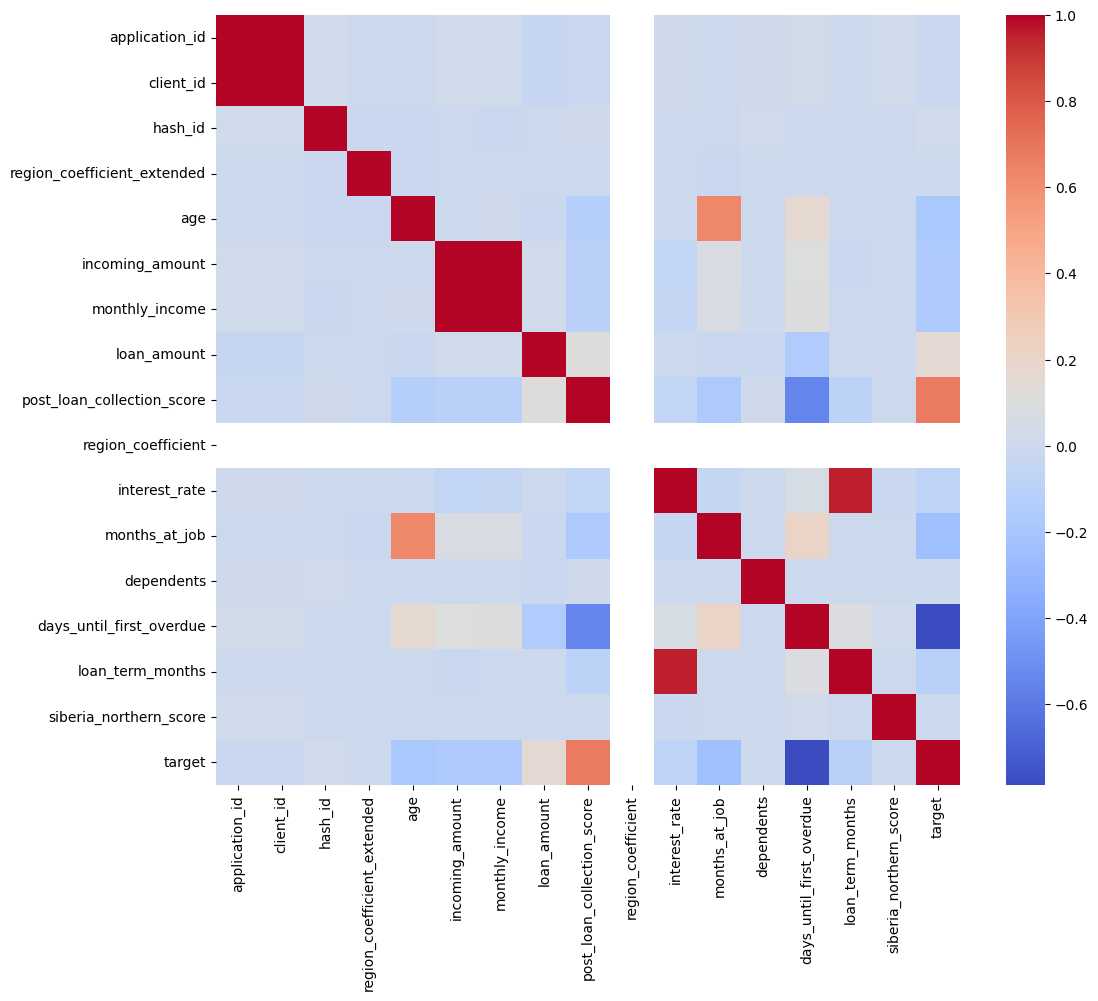

In [ ]:
plt.figure(figsize=(12, 10))
sb.heatmap(train.corr(numeric_only=True), cmap='coolwarm')
plt.show()
#Матрица корреляции, чтобы увидеть попарную корреляцию.
#Если признаки сильно коррелируют, то дропну один их двоих.
#Мультиколлинеарность не так критична именно для бустингов в отличие от линейных моделей,
#но это всё равно избыточно и лучше очистить данные.
#ТАКЖЕ здесь можно увидеть самые полезные фичи -
#это те, которые сильно коррелируют с таргетом.

В хитмап тоже несколько моментов:

1 У incoming_amount и monthly_income корреляция равна почти единице, то есть они друг друга дублируют, поэтому один из них я уберу.

2 post_loan_collection_score и days_until_first_overdue --- есть риск утечки данных, тоже дропну.



**Теперь переходим к feature engineering**

Здесь просто почищу бесполезные фичи и дубликаты.

In [ ]:
'''leak_cols = ['post_loan_collection_score', 'days_until_first_overdue']
drop_cols = ['region_coefficient']

train = train.drop(columns=leak_cols + drop_cols)
test = test.drop(columns=leak_cols + drop_cols)

train = train.drop(columns=['incoming_amount'])
test = test.drop(columns=['incoming_amount'])'''

"leak_cols = ['post_loan_collection_score', 'days_until_first_overdue']\ndrop_cols = ['region_coefficient']\n\ntrain = train.drop(columns=leak_cols + drop_cols)\ntest = test.drop(columns=leak_cols + drop_cols)\n\ntrain = train.drop(columns=['incoming_amount'])\ntest = test.drop(columns=['incoming_amount'])"

Выше я не обратила внимание на колонку internal_decision_code --- из-за нее возникла утечка данных и метрики были довольно высокие для всех моделей (около 94%).

Это по сути готовое решение банка по заявке, которое формируется
после скоринга. На этапе подачи заявки его ещё нет, поэтому его надо обязательно удалить

In [ ]:
'''leak_cols = ['post_loan_collection_score', 'days_until_first_overdue',
             'internal_decision_code']
drop_cols = ['region_coefficient']

train = train.drop(columns=leak_cols + drop_cols, errors='ignore')
test = test.drop(columns=leak_cols + drop_cols, errors='ignore')

train = train.drop(columns=['incoming_amount'], errors='ignore')
test = test.drop(columns=['incoming_amount'], errors='ignore')'''

"leak_cols = ['post_loan_collection_score', 'days_until_first_overdue', \n             'internal_decision_code']\ndrop_cols = ['region_coefficient']\n\ntrain = train.drop(columns=leak_cols + drop_cols, errors='ignore')\ntest = test.drop(columns=leak_cols + drop_cols, errors='ignore')\n\ntrain = train.drop(columns=['incoming_amount'], errors='ignore')\ntest = test.drop(columns=['incoming_amount'], errors='ignore')"

Также, передумала и ниже убрала аргумент errors - так код упадет и подсветит, что мусорные признаки не удалились (в случае опечатки)

In [ ]:
leak_cols = ['post_loan_collection_score', 'days_until_first_overdue',
             'internal_decision_code']
drop_cols = ['region_coefficient']

train = train.drop(columns=leak_cols + drop_cols)
test = test.drop(columns=leak_cols + drop_cols)

train = train.drop(columns=['incoming_amount'])
test = test.drop(columns=['incoming_amount'])

Теперь можно сделать merge по следующим ключам из доп.датасетов (bureau, previous_loans, transactions):

По client_id - бюро и прошлые займы,

По application_id - транзакции.

То есть я добавляю фичи из bureau, previous_loans
и transactions к train и test. В бюро кредитных историй есть информация о кредитной истории клиента в целом в других компаниях, а в previous_loans - информация о кредитном рейтинге клиента уже в данной компании, в transactions - какие у клиента траты по карте. То есть в этих датасетах тоже очень полезная информация о долговой нагрузке клиента, которая скорее всего повысит качество предсказания дефолта.


Из bureau беру следующие колонки: общую сумму долгов, количество счетов, максимальную просрочку за год, лимиты, текущие балансы,давность открытия.


Из previous_loans: суммы, сроки, флаг просрочки, максимальные дни просрочки, количество займов.


Из transactions: средний чек, сумму, количество транзакций,
уровень риска мерчантов.


Следующие три ячейки выполняю описанный мердж.



In [ ]:
bureau_agg = bureau.groupby('client_id').agg({
    'credit_limit': ['mean', 'sum', 'max'],
    'current_balance': ['mean', 'sum'],
    'max_dpd_last_12m': ['max', 'mean'],
    'opened_days_ago': ['min', 'max'],
    'bureau_account_id': 'count',
}).reset_index()

bureau_agg.columns = ['client_id'] + [
    'bureau_' + '_'.join(c) for c in bureau_agg.columns[1:]
]


In [ ]:
prev_agg = prev_loans.groupby('client_id').agg({
    'previous_amount': ['mean', 'sum', 'count'],
    'previous_term_months': 'mean',
    'was_overdue': ['sum', 'mean'],
    'max_overdue_days': ['max', 'mean'],
    'closed_days_ago': 'min',
}).reset_index()

prev_agg.columns = ['client_id'] + [
    'prev_' + '_'.join(c) for c in prev_agg.columns[1:]
]

In [ ]:
#помечу траты как 1 чтобы разделить для модели расходы и доходы
transactions['is_expense'] = (transactions['amount'] < 0).astype(int)

trans_agg = transactions.groupby('application_id').agg({
    'amount': ['mean', 'sum', 'std', 'count', 'min', 'max'],
    'merchant_risk_level': ['mean', 'max'],
    'is_expense': 'mean',  # добавили новую фичу — долю списаний
}).reset_index()

trans_agg.columns = ['application_id'] + [
    'trans_' + '_'.join(c) for c in trans_agg.columns[1:]
]


теперь главный мердж;
бюро и прошлые займы - по client_id

транзакции - по application_id

то же самое для test


In [ ]:
train = train.merge(bureau_agg, on='client_id', how='left')
train = train.merge(prev_agg, on='client_id', how='left')


train = train.merge(trans_agg, on='application_id', how='left')

test = test.merge(bureau_agg, on='client_id', how='left')
test = test.merge(prev_agg, on='client_id', how='left')
test = test.merge(trans_agg, on='application_id', how='left')


Еще можно искуственно ввести свою дополнительную фичу (долговая нагрузка, которая говорит о высоком риске исходящем от заемщика --- может пригодиться)

In [ ]:
train['debt_to_income'] = train['bureau_current_balance_sum'] / (train['monthly_income'] + 1) # +1 чтобы не было деления на ноль если нет дохода (то есть доход клиента 0 рублей)
test['debt_to_income'] = test['bureau_current_balance_sum'] / (test['monthly_income'] + 1) #отношение долга к доходу

train['loan_to_income'] = train['loan_amount'] / (train['monthly_income'] + 1)
test['loan_to_income'] = test['loan_amount'] / (test['monthly_income'] + 1) #отношение суммы займа к доходу


В итоге получилось создать две дополнительные фичи:

отношение долга к доходу - какую часть дохода клиент уже должен отдавать другим банкам.

отношение суммы займа к доходу - если человек просит сумму, которая в несколько раз выше его зарплаты, то это красный флаг.

Эти признаки покажут, насколько тяжело клиенту будет выплатить заём. То есть чем выше значения этих отношений, тем выше долговая нагрузка клиента.

**Настало время обучать. Я сразу подумала о CatBoostClassifier и LightGBM**

Больше склоняюсь к CatBoost по следующим причинам:

В датасетах много категориальных признаков ( это education, region, employment_type, channel, requested_product, marketing_segment, internal_decision_code, account_type, bureau_status, transaction_category). Кэтбуст с ними хорошо справляется. Нейронные сети здесь излишни, потому что данные в таблицах и классического МЛ будет достаточно. Сами по себе бустинги хороши там, где много пропусков (а их здесь много). К тому же, в lightgbm надо вручную разбираться с категориальными признаками, поэтому предпочтительней всё-таки кэтбуст.

НО из интереса я посмотрю и результаты LightGBM и сравню с CatBoost. В сравнении будет понятно, хорошо модель справляется или нет.


В качестве бэйзлайна посмотрю ещё результаты логистической регрессии.

Также я реализую 5 фолдовую кросс-валидацию для устойчивости решения. То есть я хочу ислючить случайность решения. Искомый скор будет как раз средним значением на 5 фолдах.

In [ ]:
'''!pip install catboost lightgbm -q

import catboost as cb
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer


drop = ['application_id', 'client_id', 'hash_id', 'application_date',
        'previous_loan_id', 'transaction_date'] #тут я делаю дроп бесполезных фич

X = train.drop(columns=drop + ['target'], errors='ignore')
y = train['target']
X_test = test.drop(columns=drop, errors='ignore')


cat_features = [c for c in X.columns if X[c].dtype == 'object']
print("cat features:", cat_features)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)'''

'!pip install catboost lightgbm -q\n\nimport catboost as cb\nimport lightgbm as lgb\nimport numpy as np\nfrom sklearn.model_selection import StratifiedKFold\nfrom sklearn.metrics import roc_auc_score\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.preprocessing import StandardScaler, LabelEncoder\nfrom sklearn.impute import SimpleImputer\n\n\ndrop = [\'application_id\', \'client_id\', \'hash_id\', \'application_date\',\n        \'previous_loan_id\', \'transaction_date\'] #тут я делаю дроп бесполезных фич\n\nX = train.drop(columns=drop + [\'target\'], errors=\'ignore\')\ny = train[\'target\']\nX_test = test.drop(columns=drop, errors=\'ignore\')\n\n\ncat_features = [c for c in X.columns if X[c].dtype == \'object\']\nprint("cat features:", cat_features)\n\nskf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)'

In [ ]:
!pip install catboost lightgbm -q

import catboost as cb
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

drop = ['application_id', 'client_id', 'hash_id', 'application_date',
        'previous_loan_id', 'transaction_date'] #тут я делаю дроп бесполезных фич

X = train.drop(columns=drop + ['target'], errors='ignore')
y = train['target']
X_test = test.drop(columns=drop, errors='ignore')


#сначала забыла это сделать, потом вспомнила. Без этой штуки код падает с ошибкой Invalid type for cat_feature[......feature_idx=0]=0.0 и тд., тк в test и train датасетах порядок признаков отличается.
X_test = X_test[X.columns] #поэтому надо дополнительно выровнять порядок колонок в test и train датасетах

cat_features = [c for c in X.columns if X[c].dtype == 'object']
print("cat features:", cat_features)

#5 фолдовая кросс-валидация
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cat features: ['employment_type', 'education', 'requested_product', 'channel', 'marketing_segment', 'region']


Теперь рассмотрю логрег. Он не умеет сам кодировать категориальные признаки (в отличие от Кэтбуст) и пропуски, поэтому делаю это вручную

In [ ]:
X_lr = pd.get_dummies(X, columns=cat_features, dummy_na=True)
X_lr = X_lr.fillna(-999)

lr_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_lr, y)):
    X_tr, X_val = X_lr.iloc[tr_idx], X_lr.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, random_state=42))
    ])
    model.fit(X_tr, y_tr)

    pred = model.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, pred)
    lr_scores.append(score)

    print(f"LogReg Fold {fold+1}: AUC = {score:.4f}")

print(f"\nMean LogReg AUC: {np.mean(lr_scores):.4f}")


LogReg Fold 1: AUC = 0.7587
LogReg Fold 2: AUC = 0.7430
LogReg Fold 3: AUC = 0.7931
LogReg Fold 4: AUC = 0.7282
LogReg Fold 5: AUC = 0.7245

Mean LogReg AUC: 0.7495


кэтбуст не принимает NaN в категориальных признаках, поэтому пропуски надо заполнить (ниже)
и привести к строке

In [ ]:
X_cat = X.copy()
X_test_cat = X_test.copy()

for c in cat_features:
    X_cat[c] = X_cat[c].fillna('missing').astype(str)
    X_test_cat[c] = X_test_cat[c].fillna('missing').astype(str)

cat_preds_test = np.zeros(len(X_test_cat))
cat_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_cat, y)):
    X_tr, X_val = X_cat.iloc[tr_idx], X_cat.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = cb.CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        eval_metric='AUC',
        random_seed=42,
        verbose=0,
    )
    model.fit(X_tr, y_tr, cat_features=cat_features)

    pred = model.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, pred)
    cat_scores.append(score)

    cat_preds_test += model.predict_proba(X_test_cat)[:, 1] / skf.n_splits

    print(f"CatBoost Fold {fold+1}: AUC = {score:.4f}")

print(f"\nMean CatBoost AUC: {np.mean(cat_scores):.4f}")


CatBoost Fold 1: AUC = 0.8342
CatBoost Fold 2: AUC = 0.8081
CatBoost Fold 3: AUC = 0.8178
CatBoost Fold 4: AUC = 0.8324
CatBoost Fold 5: AUC = 0.8290

Mean CatBoost AUC: 0.8243


In [ ]:
X_lgb = X.copy()
X_test_lgb = X_test.copy()

for c in cat_features:
    le = LabelEncoder() #кодирую категориальне признаки и объединяю тест и трейн, чтобы энкодер увидел все категории
    all_vals = pd.concat([X_lgb[c], X_test_lgb[c]], axis=0).astype(str)
    le.fit(all_vals)
    X_lgb[c] = le.transform(X_lgb[c].astype(str))
    X_test_lgb[c] = le.transform(X_test_lgb[c].astype(str))

lgb_preds_test = np.zeros(len(X_test_lgb))
lgb_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_lgb, y)):
    X_tr, X_val = X_lgb.iloc[tr_idx], X_lgb.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbose=-1,
    )
    model.fit(X_tr, y_tr)

    pred = model.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, pred)
    lgb_scores.append(score)

    lgb_preds_test += model.predict_proba(X_test_lgb)[:, 1] / skf.n_splits

    print(f"LightGBM Fold {fold+1}: AUC = {score:.4f}")

print(f"\nMean LightGBM AUC: {np.mean(lgb_scores):.4f}")


LightGBM Fold 1: AUC = 0.8190
LightGBM Fold 2: AUC = 0.7985
LightGBM Fold 3: AUC = 0.8002
LightGBM Fold 4: AUC = 0.8170
LightGBM Fold 5: AUC = 0.8196

Mean LightGBM AUC: 0.8109


### Сравнение моделей

| Модель | Mean AUC |
|---|---|
| LogReg | 0.7496 |
| CatBoost | 0.8243 |
| LightGBM | 0.8104 |


Ячейка для выгрузки решения в .csv

In [ ]:
import os

#усредняю предсказания двух моделей
best_preds = cat_preds_test * 0.6 + lgb_preds_test * 0.4

submission = pd.DataFrame({
    "application_id": test["application_id"],
    "target": best_preds
})

save_path = '/content/drive/MyDrive/SUBMISSION_SCORING_SIFT/'
os.makedirs(save_path, exist_ok=True)

submission.to_csv(save_path + "submission.csv", index=False)
submission.head()

,application_id,target
0,102531,0.790456
1,107213,0.669781
2,100238,0.210349
3,104918,0.229349
4,106480,0.318305
